# NHL Player Style: EDA & Feature Building
**DSC 148 Course Project**

This notebook covers the **Dataset** component of the report: load the data, build
the per-60 "style fingerprint" features, explore how positions separate, and produce
the figures we'll use in the write-up. It also sets up both prediction targets
(forward-vs-defense and 4-class C/L/R/D) for the modeling notebook.

Run cells top to bottom. Figures auto-save into a `figures/` folder.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 60)

## 1. Load the data
`player_games.csv` is one row per (player, game) and is our supervised dataset.
`player_seasons.csv` is the season aggregate the API gave us directly (we'll mostly
rebuild our own aggregate below so we control exactly which stats become features).

In [2]:
games = pd.read_csv("player_games.csv")
print("player-games:", games.shape)
print("seasons covered:", sorted(games["seasonId"].unique()))
print("position counts:\n", games["positionCode"].value_counts())
games.head()

player-games: (94429, 51)
seasons covered: [20222023, 20232024]
position counts:
 positionCode
D    31857
C    30310
L    17829
R    14433
Name: count, dtype: int64


,assists,evGoals,evPoints,faceoffWinPct,gameDate,gameId,gameWinningGoals,gamesPlayed,goals,homeRoad,lastName,opponentTeamAbbrev,otGoals,penaltyMinutes,playerId,plusMinus,points,pointsPerGame,positionCode,ppGoals,ppPoints,shGoals,shPoints,shootingPct,shootsCatches,shots,skaterFullName,teamAbbrev,timeOnIcePerGame,blockedShots,blockedShotsPer60,emptyNetAssists,emptyNetGoals,emptyNetPoints,firstGoals,giveaways,giveawaysPer60,hits,hitsPer60,missedShotCrossbar,missedShotFailedBankAttempt,missedShotGoalpost,missedShotOverNet,missedShotShort,missedShotWideOfNet,missedShots,shotAttemptsBlocked,takeaways,takeawaysPer60,totalShotAttempts,seasonId
0,0,0,0,NaN,2022-10-13,2022020012,0,1,0,R,Smith,PHI,0,0,8474090,-2,0,0.0,D,0,0,0,0,0.0,L,1,Brendan Smith,NJD,615.0,0,0.00,NaN,0,NaN,0,0,0.00,4,23.41,0,NaN,0,1,NaN,1,2,1,0,0.00,4,20222023
1,0,0,0,NaN,2022-10-15,2022020028,0,1,0,H,Smith,DET,0,2,8474090,-1,0,0.0,D,0,0,0,0,0.0,L,1,Brendan Smith,NJD,989.0,3,10.92,NaN,0,NaN,0,0,0.00,1,3.64,0,NaN,0,0,NaN,0,0,2,0,0.00,3,20222023
2,0,0,0,NaN,2022-10-18,2022020048,0,1,0,H,Smith,ANA,0,9,8474090,0,0,0.0,D,0,0,0,0,0.0,L,2,Brendan Smith,NJD,567.0,0,0.00,NaN,0,NaN,0,1,6.34,3,19.04,0,NaN,0,0,NaN,1,1,0,1,6.34,3,20222023
3,0,0,0,NaN,2022-10-20,2022020066,0,1,0,R,Smith,NYI,0,2,8474090,1,0,0.0,D,0,0,0,0,NaN,L,0,Brendan Smith,NJD,929.0,4,15.50,NaN,0,NaN,0,0,0.00,1,3.87,0,NaN,0,0,NaN,0,0,1,0,0.00,1,20222023
4,0,0,0,NaN,2022-10-22,2022020075,0,1,0,H,Smith,SJS,0,2,8474090,0,0,0.0,D,0,0,0,0,NaN,L,0,Brendan Smith,NJD,498.0,1,7.22,NaN,0,NaN,0,0,0.00,2,14.45,0,NaN,0,0,NaN,0,0,1,0,0.00,1,20222023


## 2. Build player-season "fingerprints"
Style is a per-player property, so we aggregate each player's games within a season,
then convert raw counts into **per-60-minute rates**. Per-60 rates are the standard
hockey way to compare players regardless of ice time, so a 4th-liner and a star are
compared on *how* they play, not *how much*.

`per60 = stat / total_seconds_on_ice * 3600`

In [3]:
# Counting stats we turn into per-60 rate features (the fingerprint).
counting = ["goals","assists","points","shots","blockedShots","hits",
            "takeaways","giveaways","penaltyMinutes","missedShots","totalShotAttempts"]

agg = (games
       .groupby(["playerId","skaterFullName","positionCode","seasonId"])
       .agg(total_toi=("timeOnIcePerGame","sum"),
            games=("gameId","count"),
            **{c:(c,"sum") for c in counting})
       .reset_index())

# Drop very-low-minute players: style estimates are noisy with tiny samples.
MIN_MINUTES = 200
before = len(agg)
agg = agg[agg["total_toi"] >= MIN_MINUTES*60].copy()
print(f"dropped {before-len(agg)} low-minute player-seasons; kept {len(agg)}")

# Build per-60 features.
for c in counting:
    agg[f"{c}_per60"] = agg[c] / (agg["total_toi"]/3600)
feat_cols = [f"{c}_per60" for c in counting]
agg[feat_cols] = agg[feat_cols].fillna(0)
agg[["skaterFullName","positionCode","games"] + feat_cols].head()

dropped 432 low-minute player-seasons; kept 1443


,skaterFullName,positionCode,games,goals_per60,assists_per60,points_per60,shots_per60,blockedShots_per60,hits_per60,takeaways_per60,giveaways_per60,penaltyMinutes_per60,missedShots_per60,totalShotAttempts_per60
0,Eric Staal,C,72,0.819459,0.877992,1.697451,6.204475,2.633975,1.580385,1.931582,1.814516,1.521852,2.107180,10.711498
1,Ryan Suter,D,82,0.107712,0.789891,0.897603,3.303181,4.128976,2.908235,0.825795,1.615686,0.933508,2.118344,8.473376
2,Ryan Suter,D,82,0.077266,0.579499,0.656765,3.940591,4.288290,3.322459,0.618132,1.158997,1.081731,2.356628,9.812843
3,Jeff Carter,C,79,0.720355,0.886590,1.606945,7.702253,2.992242,4.432952,1.440709,1.828593,1.662357,2.493535,13.298855
4,Jeff Carter,C,72,0.729215,0.265169,0.994384,5.966301,2.187644,5.502256,1.524721,1.325845,0.795507,2.916858,11.601142


## 3. Define the two prediction targets
- **Binary:** forward (C/L/R) vs. defense (D). The clean, high-signal task.
- **4-class:** C / L / R / D. Harder, because left vs. right wing is positional
  convention more than playing style. We expect the model to struggle on exactly
  that split, which is itself a finding.

In [4]:
agg["is_forward"] = (agg["positionCode"] != "D").astype(int)   # 1 = forward, 0 = defense
agg["pos4"] = agg["positionCode"]                              # C / L / R / D
print("binary  :", agg["is_forward"].value_counts().to_dict())
print("4-class :", agg["pos4"].value_counts().to_dict())

binary  : {1: 935, 0: 508}
4-class : {'D': 508, 'C': 446, 'L': 266, 'R': 223}


## 4. How do positions separate on key stats?
Defensemen should block far more shots; forwards should take more shots and score
more. If this separation is visible, our features have real signal.

              shots_per60  blockedShots_per60  hits_per60  goals_per60  \
positionCode                                                             
C                    6.79                2.24        4.91         0.78   
D                    4.19                4.78        4.51         0.22   
L                    7.30                1.98        6.38         0.83   
R                    7.64                2.00        5.46         0.86   

              takeaways_per60  giveaways_per60  
positionCode                                    
C                        1.70             1.46  
D                        0.96             1.62  
L                        1.63             1.47  
R                        1.68             1.44  


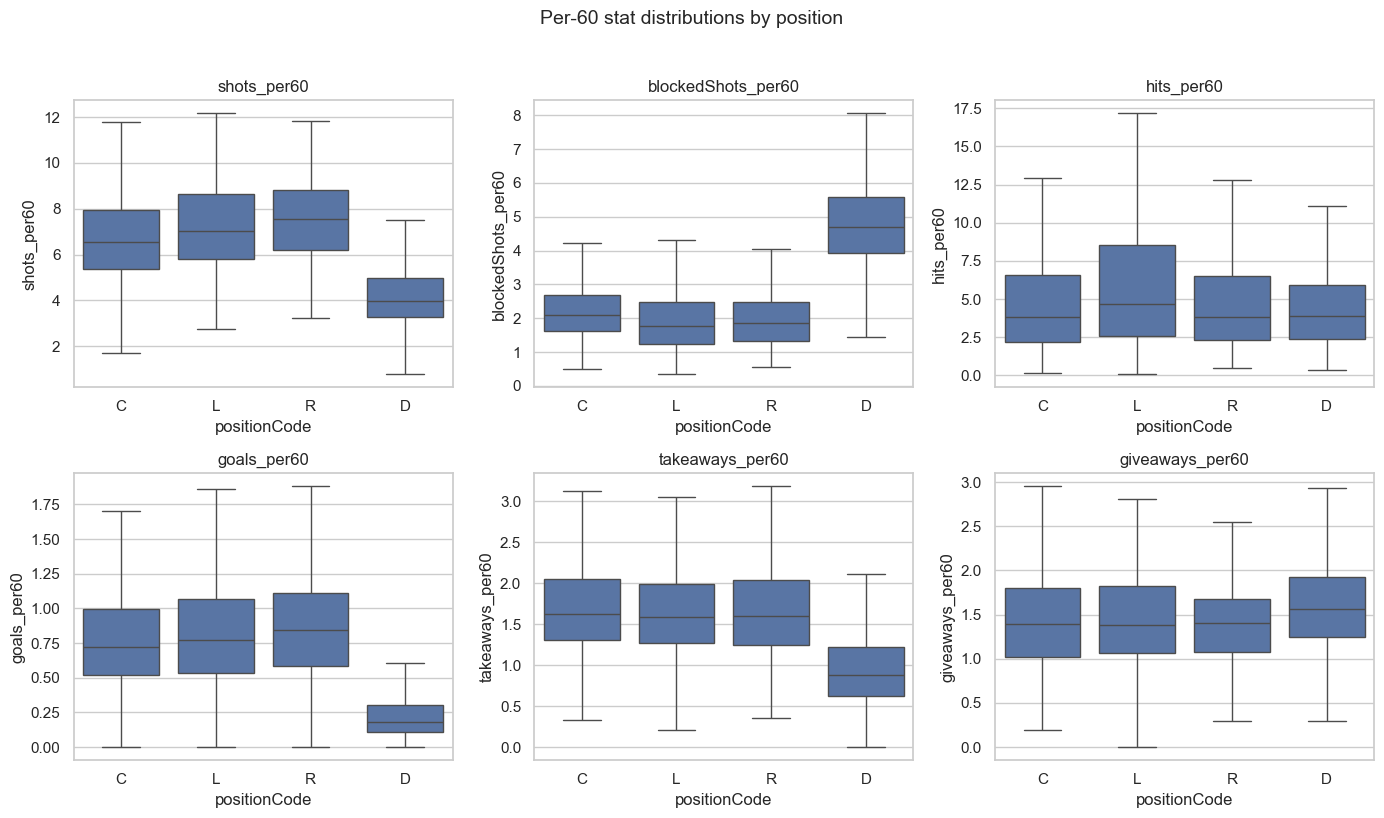

In [5]:
key = ["shots_per60","blockedShots_per60","hits_per60","goals_per60",
       "takeaways_per60","giveaways_per60"]
summary = agg.groupby("positionCode")[key].mean().round(2)
print(summary)

fig, axes = plt.subplots(2, 3, figsize=(14,8))
for ax, stat in zip(axes.ravel(), key):
    sns.boxplot(data=agg, x="positionCode", y=stat, order=["C","L","R","D"],
                ax=ax, showfliers=False)
    ax.set_title(stat)
fig.suptitle("Per-60 stat distributions by position", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGDIR/"position_separation.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Feature correlations
Helps us spot redundant features (e.g. points = goals + assists) before modeling.

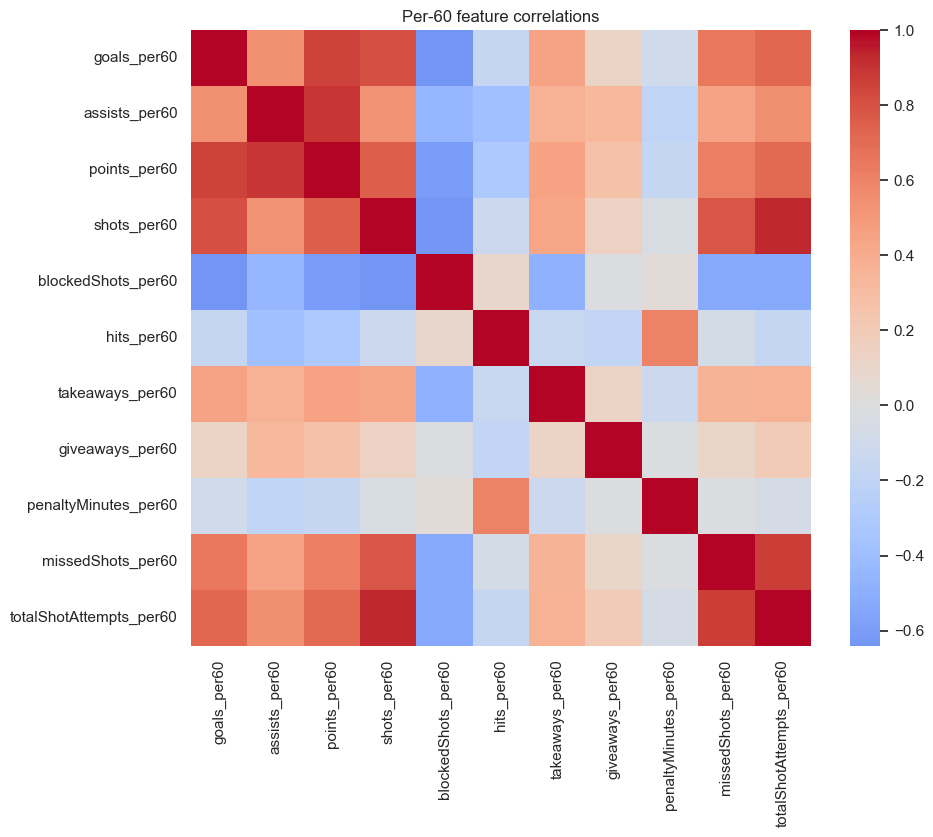

In [6]:
corr = agg[feat_cols].corr()
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Per-60 feature correlations")
fig.savefig(FIGDIR/"feature_correlations.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. The style space: PCA projection
Project the high-dimensional fingerprints down to 2D so we can *see* the structure.
Color by position. We expect defensemen to occupy a different region than forwards.
This is a centerpiece figure for the report.

variance explained by 2 components: [0.498 0.153]


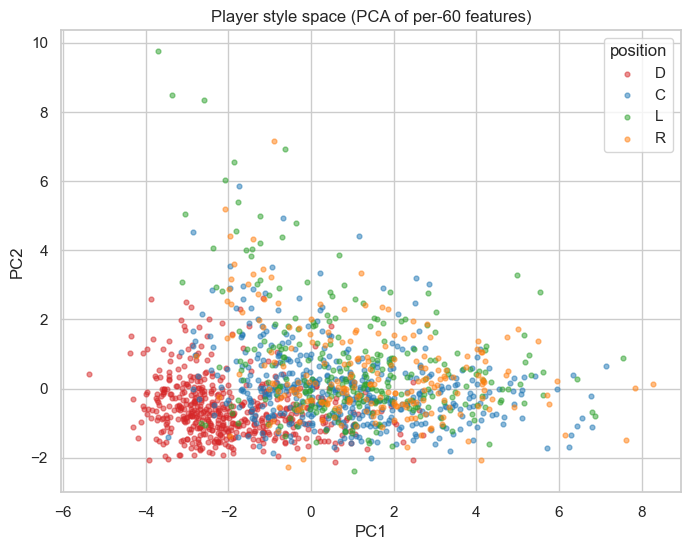

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(agg[feat_cols])
pca = PCA(n_components=2).fit(X)
proj = pca.transform(X)
print("variance explained by 2 components:", pca.explained_variance_ratio_.round(3))

fig, ax = plt.subplots(figsize=(8,6))
palette = {"D":"#d62728","C":"#1f77b4","L":"#2ca02c","R":"#ff7f0e"}
for pos, color in palette.items():
    m = agg["positionCode"] == pos
    ax.scatter(proj[m,0], proj[m,1], s=12, alpha=0.5, label=pos, color=color)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Player style space (PCA of per-60 features)")
ax.legend(title="position")
fig.savefig(FIGDIR/"style_space_pca.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. First clustering pass (K-Means)
Discover styles *without* using the position labels, then check how the clusters
line up with real positions. If clusters cut across positions, that's the
interesting "style transcends position" story.

C:\Users\owenm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


cluster vs position:
positionCode    C    D    L    R
cluster                         
0             246   95  128  103
1             117   12   78   88
2              44   15   48   28
3              39  386   12    4


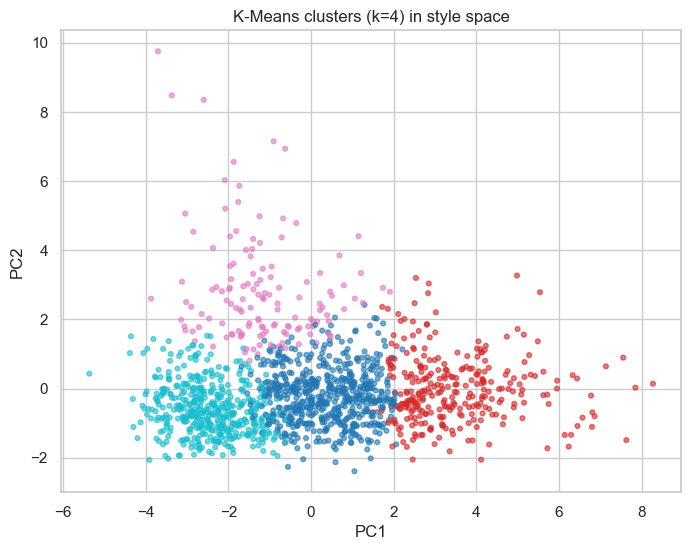

In [8]:
from sklearn.cluster import KMeans

k = 4
km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
agg["cluster"] = km.labels_

print("cluster vs position:")
print(pd.crosstab(agg["cluster"], agg["positionCode"]))

# Visualize clusters in the same PCA space
fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(proj[:,0], proj[:,1], c=agg["cluster"], cmap="tab10", s=12, alpha=0.6)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title(f"K-Means clusters (k={k}) in style space")
fig.savefig(FIGDIR/"kmeans_clusters.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Save the processed dataset
Write the player-season fingerprints (features + both targets + cluster labels) so
the modeling notebook can load it directly.

In [9]:
out_cols = (["playerId","skaterFullName","positionCode","seasonId","games","total_toi"]
            + feat_cols + ["is_forward","pos4","cluster"])
agg[out_cols].to_csv("player_fingerprints.csv", index=False)
print("saved player_fingerprints.csv:", agg[out_cols].shape)

saved player_fingerprints.csv: (1443, 20)


## Next steps (modeling notebook)
- Baselines: logistic regression, naive Bayes (both from DSC 148).
- Proposed model: gradient boosting on the per-60 fingerprints.
- Evaluate accuracy + F1 for both targets; compare F-vs-D against the harder 4-class.
- Ablation: drop feature groups (scoring vs. defensive) and watch performance move.
- Case study: the players the model misclassifies are the stylistic outliers.